In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import os, sys, time
import geopandas as gpd

REPO = Path(os.getcwd()).parent
DATA_ROOT = REPO.parent.parent / 'Data' / 'replication_package'
PLOT_ROOT = DATA_ROOT.parent.parent / 'Plots' / 'Groups'

sys.path.insert(0, os.path.join(REPO, 'Code', 'tools'))
import inequality_analyzers as ia

In [2]:
# Load CBOS data
cbos = pd.read_csv(DATA_ROOT / 'CBOS' / 'CBOS_survey.csv', low_memory=False)

# Load LIS Voiv
lis_voiv = pd.read_csv(DATA_ROOT / 'LIS' / 'LIS_Voiv.csv')
# Load LIS Groups
lis_groups = pd.read_csv(DATA_ROOT / 'LIS' / 'LIS_Groups.csv')

In [3]:
# We create relevant columns
cbos["H_total_income"] = cbos["income_hh_t_imputed"]        # Total household income: income per household member multiplied by household size
cbos["P_income"] = cbos["income_p_imputed"]

# Regional aspect:
# - 1990-1998: old voivodeships (49 units) -> location_old_L
# - 1999-2.2017: new voivodeships (16 units) -> location_new_L
# - 3.2017-12.2017: macroregions (6 units) -> macroregion

# Deflators (for base year in [1986, 1990, 2017, 2023]):
# - deflator_YYYY: average yearly deflator, with base year in YYYY.
# - deflator_YYYY_m: monthly deflator, with base year in January of YYYY.
relevant_check_columns = ['sex_L', 'age', 'educ_2000_L', 'household_size', 'weight_VOIV_h_NORM', 'income_hh', 'H_total_income']

In [4]:
# Load geometry for NEW voivodeships (16 units, 1999-2017)
region_gdf = gpd.read_file(DATA_ROOT / 'geometry' / 'geometry.gpkg', layer='new_voiv_groups')

import shapely

geom_115 = region_gdf.loc[region_gdf['id'] == 'Group 115', 'geometry'].values[0]
geom_114 = region_gdf.loc[region_gdf['id'] == 'Group 114', 'geometry'].values[0]
new_geom_115 = shapely.difference(geom_115, geom_114)

region_gdf.loc[region_gdf['id'] == 'Group 115', 'geometry'] = new_geom_115

In [5]:
# ════════════════════════════════════════════════════════════════════════════
# ► GLOBAL YEAR — change this single variable to produce the analysis
#   for different years.  Valid range: 1999–2016 (new voivodeships era)
# ════════════════════════════════════════════════════════════════════════════
YEAR = 2016

# Initialize analyzers ───────────────────────────────────────────────────────
# CBOS: microdata, weighted by VOIV×city-size reweighting scheme
cbos_a = ia.CBOSAnalyzer(cbos,
                         income_col='H_total_income',
                         weight_col='weight_VOIV_100_500_h_NORM',
                         deflator_col='deflator_2023_m')

# LIS Groups: pre-computed statistics per voivodeship×city-size group
lis_groups_a = ia.LISAnalyzer(lis_groups,
                              income_type='hitotalnet',
                              deflator_col='deflator_2023')

# Build a name-lookup from the geometry layer (id → name)
group_name_map = dict(zip(region_gdf['id'], region_gdf['name']))

print("CBOS:", cbos_a.summary())
print("LIS Groups:", lis_groups_a.summary())
print(f"\nGeometry groups: {len(region_gdf)} | Name map sample: {dict(list(group_name_map.items())[:3])}")

CBOS: {'n_observations': 355336, 'year_range': (np.int64(1990), np.int64(2017)), 'n_years': 28, 'income_col': 'H_total_income', 'weight_col': 'weight_VOIV_100_500_h_NORM', 'deflator_col': 'deflator_2023_m', 'income_non_null': np.int64(352371), 'weight_non_null': np.int64(355336)}
LIS Groups: {'income_type': 'hitotalnet', 'n_regions': 141, 'year_range': (np.int64(1999), np.int64(2023)), 'n_metrics': 31, 'available_metrics': ['N_total', 'Nw_total', 'mean', 'median', 'p10', 'p25', 'p75', 'p90', 'p99', 'p90p10', 'p90p50', 'p50p10', 'gini', 'theil', 'palma', 'N_Bottom_50', 'Nw_Bottom_50', 'Bottom_50', 'N_P50_90', 'Nw_P50_90', 'P50_90', 'N_Top_10', 'Nw_Top_10', 'Top_10', 'N_Top_1', 'Nw_Top_1', 'Top_1', 'share_Bottom_50', 'share_P50_90', 'share_Top_10', 'share_Top_1'], 'deflator': 'deflator_2023'}

Geometry groups: 290 | Name map sample: {'Group 1': 'village, city below 20k, city 20k-100k, city 100k-500k in Dolnośląskie', 'Group 2': 'city 200k-500k, city above 500k, city 100k-200k in Dolnoślą

In [6]:
# Set up for plotting
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from matplotlib.lines import Line2D

sns.set_style("whitegrid")
plt.rcParams.update({
    'figure.figsize': (6, 6),
    'font.size': 11.0,
    'font.family': 'serif',
    'font.serif': 'Palatino',
    'axes.titlesize': 'medium',
    'figure.titlesize': 'large',
    'legend.fontsize': 'medium',
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'figure.autolayout': True,
    'text.usetex': True,
    'text.latex.preamble': r"\usepackage[T1]{fontenc}\usepackage[utf8]{inputenc}\usepackage{amsmath}\usepackage{amssymb}\usepackage{siunitx}[=v2]",
})

COLORS = {
    'CBOS': ["#274690", "#3B7DD8", "#2BB3C0", "#1F9A8A", "#6B57C9", "#A78FFF"],
    'LIS':  ["#8B2E2E", "#B63E3E", "#E06B57", "#C75B7C", "#9A2442", "#5B1F2E"],
}

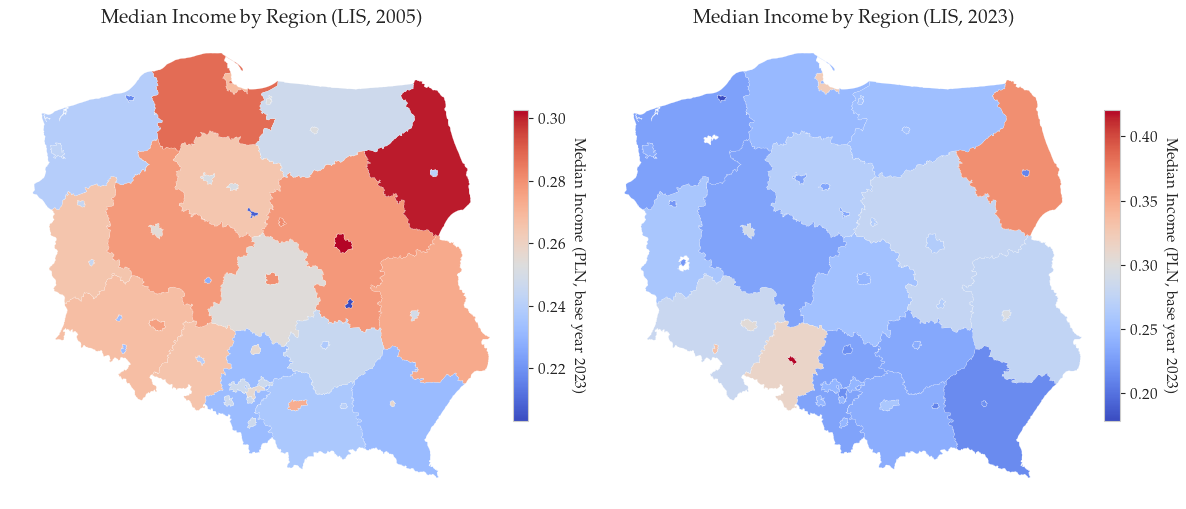

In [7]:
# ── Median income map and top_10: LIS side by side (YEAR) ───────────────────────

YEAR_1 = 2005
YEAR_2 = 2023

lis_regional = lis_groups_a.regional_panel(metrics=['share_Top_10'])
lis_regional_1 = lis_regional[lis_regional['year'] == YEAR_1].copy()
lis_regional_1['name']  = lis_regional_1['region'].map(group_name_map)
lis_regional_2 = lis_regional[lis_regional['year'] == YEAR_2].copy()
lis_regional_2['name']  = lis_regional_2['region'].map(group_name_map)

gdf = region_gdf.copy()
gdf['lis_1']  = gdf['id'].map(lis_regional_1.set_index('region')['share_Top_10'])
gdf['lis_2']  = gdf['id'].map(lis_regional_2.set_index('region')['share_Top_10'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Two maps side by side two bars side by side
vmin_1 = lis_regional_1['share_Top_10'].min()
vmax_1 = lis_regional_1['share_Top_10'].max()
vmin_2 = lis_regional_2['share_Top_10'].min()
vmax_2 = lis_regional_2['share_Top_10'].max()

cmap = plt.cm.coolwarm
norm_1 = mpl.colors.Normalize(vmin=vmin_1, vmax=vmax_1)
norm_2 = mpl.colors.Normalize(vmin=vmin_2, vmax=vmax_2)
sm_1 = plt.cm.ScalarMappable(cmap=cmap, norm=norm_1)
sm_2 = plt.cm.ScalarMappable(cmap=cmap, norm=norm_2)


# Plot YEAR_1 map
gdf.plot(column='lis_1', ax=ax1, legend=False, cmap=cmap, norm=norm_1, edgecolor='white', linewidth=0.1)
ax1.set_title(f'Median Income by Region (LIS, {YEAR_1})', fontsize=14)
ax1.axis('off')
# Plot YEAR_2 map
gdf.plot(column='lis_2', ax=ax2, legend=False, cmap=cmap, norm=norm_2, edgecolor='white', linewidth=0.1)
ax2.set_title(f'Median Income by Region (LIS, {YEAR_2})', fontsize=14)
ax2.axis('off')

# Colorbar
cbar_1 = fig.colorbar(sm_1, ax=ax1, orientation='vertical', fraction=0.03, pad=0)
cbar_1.set_label('Median Income (PLN, base year 2023)', rotation=270, labelpad=15)
cbar_2 = fig.colorbar(sm_2, ax=ax2, orientation='vertical', fraction=0.03, pad=0)
cbar_2.set_label('Median Income (PLN, base year 2023)', rotation=270, labelpad=15)

plt.tight_layout()
plt.savefig(PLOT_ROOT / f'LIS_top_10_income_map_{YEAR_1}_{YEAR_2}.png', bbox_inches='tight')
plt.show()

/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_35872/2985919909.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


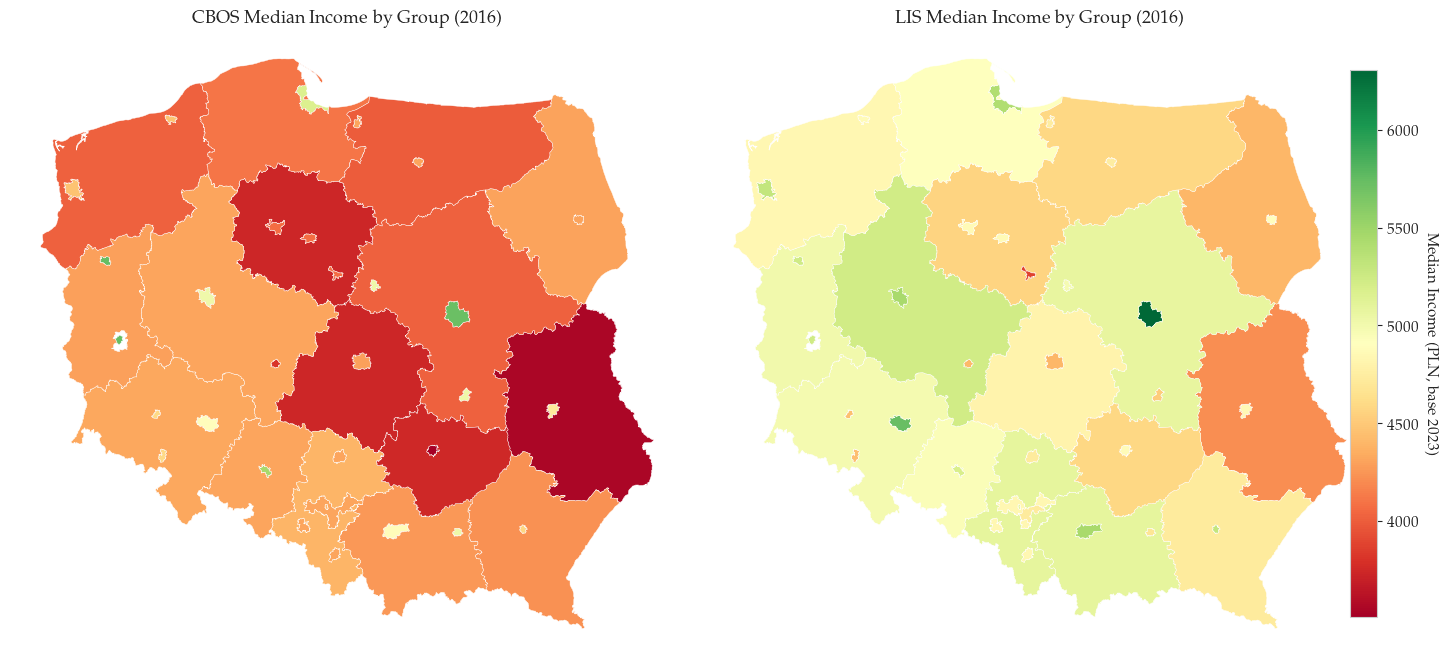

In [8]:
# ── Median income map: CBOS vs LIS side by side (YEAR) ───────────────────────
cbos_regional = cbos_a.regional_metrics(year=YEAR, region_col='G_VOIV_100_500')
lis_regional = lis_groups_a.regional_panel(metrics=['median'])
lis_regional = lis_regional[lis_regional['year'] == YEAR].copy()

# Map group IDs to geometry names for label display
cbos_regional['name'] = cbos_regional['region'].map(group_name_map)
lis_regional['name']  = lis_regional['region'].map(group_name_map)

# Join to geometry via 'id'
gdf = region_gdf.copy()
gdf['cbos'] = gdf['id'].map(cbos_regional.set_index('region')['median'])
gdf['lis']  = gdf['id'].map(lis_regional.set_index('region')['median'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
vmin = min(gdf['cbos'].min(), gdf['lis'].min())
vmax = max(gdf['cbos'].max(), gdf['lis'].max())
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.RdYlGn
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

gdf.plot(column='cbos', ax=ax1, legend=False, cmap=cmap, norm=norm, edgecolor='white', linewidth=0.3)
ax1.set_title(f'CBOS Median Income by Group ({YEAR})', fontsize=13)
ax1.axis('off')

gdf.plot(column='lis', ax=ax2, legend=False, cmap=cmap, norm=norm, edgecolor='white', linewidth=0.3)
ax2.set_title(f'LIS Median Income by Group ({YEAR})', fontsize=13)
ax2.axis('off')

cbar = fig.colorbar(sm, ax=[ax1, ax2], orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_label('Median Income (PLN, base 2023)', rotation=270, labelpad=15)
plt.tight_layout()
plt.savefig(PLOT_ROOT / f'median_income_map_groups_{YEAR}.png', bbox_inches='tight')
plt.show()

/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_35872/3025129393.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


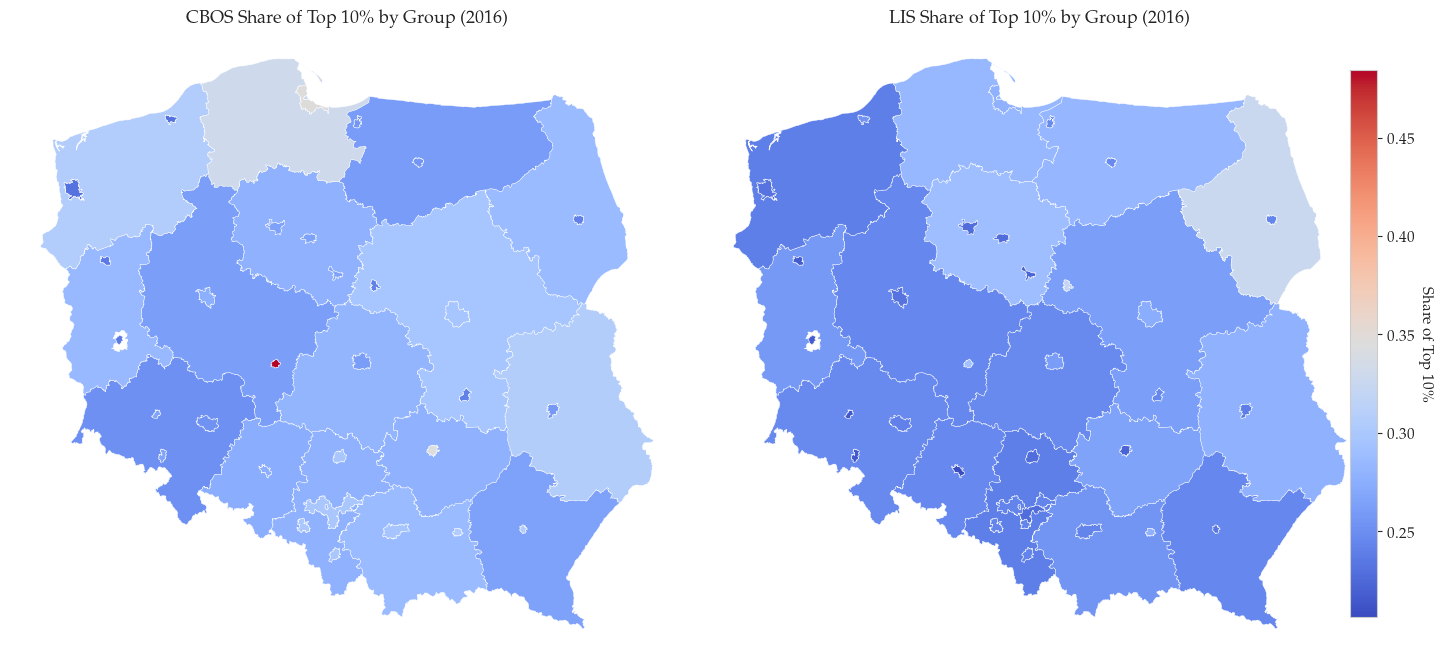

In [9]:
# ── Share Top 10% map: CBOS vs LIS side by side (YEAR) ───────────────────────
cbos_reg_t10 = cbos_a.regional_metrics(year=YEAR, region_col='G_VOIV_100_500')
lis_reg_t10 = lis_groups_a.regional_panel(metrics=['share_Top_10'])
lis_reg_t10 = lis_reg_t10[lis_reg_t10['year'] == YEAR].copy()

gdf = region_gdf.copy()
gdf['cbos'] = gdf['id'].map(cbos_reg_t10.set_index('region')['share_Top_10'])
gdf['lis']  = gdf['id'].map(lis_reg_t10.set_index('region')['share_Top_10'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
vmin = min(gdf['cbos'].min(), gdf['lis'].min())
vmax = max(gdf['cbos'].max(), gdf['lis'].max())
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.coolwarm
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

gdf.plot(column='cbos', ax=ax1, legend=False, cmap=cmap, norm=norm, edgecolor='white', linewidth=0.3)
ax1.set_title(f'CBOS Share of Top 10\\% by Group ({YEAR})', fontsize=13)
ax1.axis('off')

gdf.plot(column='lis', ax=ax2, legend=False, cmap=cmap, norm=norm, edgecolor='white', linewidth=0.3)
ax2.set_title(f'LIS Share of Top 10\\% by Group ({YEAR})', fontsize=13)
ax2.axis('off')

cbar = fig.colorbar(sm, ax=[ax1, ax2], orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_label('Share of Top 10\\%', rotation=270, labelpad=15)
plt.tight_layout()
plt.savefig(PLOT_ROOT / f'share_top_10_map_groups_{YEAR}.png', bbox_inches='tight')
plt.show()

In [10]:
# ── Theil between/within decomposition (voiv×city-size groups, 1999-2016) ────
theil_ts = cbos_a.regional_theil_timeseries('G_VOIV_100_500', year_range=(1999, 2023))
display(theil_ts[['year', 'total_theil', 'between', 'within', 'between_pct', 'within_pct']].round(4))

,year,total_theil,between,within,between_pct,within_pct
0,1999,0.2679,0.0144,0.2535,5.3805,94.6195
1,2000,0.2608,0.0111,0.2497,4.2585,95.7415
2,2001,0.2674,0.0071,0.2603,2.6368,97.3632
3,2002,0.2840,0.0107,0.2733,3.7613,96.2387
4,2003,0.5307,0.0259,0.5048,4.8811,95.1189
5,2004,0.2584,0.0100,0.2484,3.8555,96.1445
6,2005,0.2804,0.0089,0.2715,3.1754,96.8246
7,2006,0.3586,0.0064,0.3523,1.7712,98.2288
8,2007,0.4686,0.0102,0.4584,2.1733,97.8267
9,2008,0.3691,0.0095,0.3596,2.5807,97.4193


In [11]:
'''
# ── Theil group contributions: which groups drive total inequality? ───────────
# CBOS: per-group contributions for YEAR
cbos_contrib = cbos_a.theil_contributions(YEAR, 'G_VOIV_100_500')
cbos_contrib['name'] = cbos_contrib['group'].map(group_name_map)
print(f"=== CBOS: Group contributions to total Theil T ({YEAR}) ===")
display(cbos_contrib.sort_values('total_contribution', ascending=False)
        [['name', 'group', 'income_share', 'between_contribution', 'within_contribution',
          'total_contribution', 'contribution_pct']].round(4))

# CBOS contribution timeseries (1999-2016)
cbos_contrib_ts = cbos_a.theil_contribution_timeseries('G_VOIV_100_500',
                                                        year_range=(1999, 2023))
cbos_contrib_ts['name'] = cbos_contrib_ts['group'].map(group_name_map)
print(f"\nCBOS panel: {cbos_contrib_ts.shape} | Groups: {cbos_contrib_ts['group'].nunique()}")
'''
# LIS: per-group contributions for YEAR
lis_contrib = lis_groups_a.theil_contributions(YEAR)
lis_contrib['name'] = lis_contrib['group'].map(group_name_map)
print(f"\n=== LIS: Group contributions to total Theil T ({YEAR}) ===")
display(lis_contrib.sort_values('total_contribution', ascending=False)
        [['name', 'group', 'income_share', 'between_contribution', 'within_contribution',
          'total_contribution', 'contribution_pct']].round(4))

# LIS contribution timeseries (1999-2016)
lis_contrib_ts = lis_groups_a.theil_contribution_timeseries(year_range=(1999, 2023))
lis_contrib_ts['name'] = lis_contrib_ts['group'].map(group_name_map)
print(f"\nLIS panel: {lis_contrib_ts.shape} | Groups: {lis_contrib_ts['group'].nunique()}")


=== LIS: Group contributions to total Theil T (2016) ===


,name,group,income_share,between_contribution,within_contribution,total_contribution,contribution_pct
1,"city 200k-500k, city above 500k in Mazowieckie",Group 114,0.0800,0.0234,0.0192,0.0426,20.5896
4,"village, city below 20k, city 20k-100k in Mazo...",Group 129,0.0793,0.0008,0.0171,0.0179,8.6408
25,"village, city below 20k, city 20k-100k in Wiel...",Group 266,0.0663,0.0013,0.0122,0.0135,6.5331
0,"village, city below 20k, city 20k-100k in Mało...",Group 108,0.0540,0.0010,0.0105,0.0116,5.5966
14,"village, city below 20k, city 20k-100k in Pomo...",Group 194,0.0383,0.0006,0.0098,0.0104,5.0267
16,"village, city below 20k, city 20k-100k in Śląskie",Group 209,0.0613,-0.0008,0.0109,0.0101,4.8750
13,"city above 500k, city 100k-500k in Pomorskie",Group 185,0.0256,0.0037,0.0060,0.0097,4.6827
11,"village, city below 20k, city 20k-100k in Doln...",Group 18,0.0522,-0.0017,0.0096,0.0079,3.8155
15,"city 200k-500k, city above 500k, city 100k-200...",Group 2,0.0243,0.0032,0.0043,0.0074,3.5953
38,"city 200k-500k, city above 500k in Małopolskie",Group 85,0.0261,0.0015,0.0049,0.0063,3.0526



LIS panel: (832, 11) | Groups: 141


In [12]:
'''# ── Top-10 groups by average contribution (CBOS, 1999-2016) ─────────────────
avg_contrib = (cbos_contrib_ts.groupby('group')['total_contribution']
               .mean().sort_values(ascending=False))
top10 = avg_contrib.head(10).index.tolist()
top10_names = [group_name_map.get(g, g) for g in top10]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
fig.subplots_adjust(hspace=0.08, bottom=0.22)
cmap_c = plt.cm.tab20
colors_10 = [cmap_c(i) for i in range(10)]

for i, grp in enumerate(top10):
    d = cbos_contrib_ts[cbos_contrib_ts['group'] == grp].sort_values('year')
    ax1.plot(d['year'], d['total_contribution'], color=colors_10[i], lw=1.5)
    ax2.plot(d['year'], d['contribution_pct'],   color=colors_10[i], lw=1.5)

ax1.set_ylabel('Contribution to total Theil')
ax1.set_title(r'\textbf{CBOS}: Top-10 group contributions (total = between + within)',
              fontsize=11, loc='left')
ax2.set_ylabel(r'Share of total Theil (\%)')
ax2.set_xlabel('Year')
ax2.set_title(r'\textbf{CBOS}: Contribution shares', fontsize=11, loc='left')

# Short labels for legend (truncate long names)
short = [n[:30] for n in top10_names]
_h = [Line2D([0],[0], color=colors_10[i], lw=2) for i in range(10)]
fig.legend(_h, short, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, 0.0), frameon=False,
           handlelength=1.5, handletextpad=0.5, columnspacing=1.2, fontsize=7)
fig.suptitle(f'Group contributions to Theil T inequality (1999--2016)', fontsize=13)
plt.savefig(PLOT_ROOT / "theil_contributions_top10_groups_1999_2016.png", bbox_inches='tight')
plt.show()'''

'# ── Top-10 groups by average contribution (CBOS, 1999-2016) ─────────────────\navg_contrib = (cbos_contrib_ts.groupby(\'group\')[\'total_contribution\']\n               .mean().sort_values(ascending=False))\ntop10 = avg_contrib.head(10).index.tolist()\ntop10_names = [group_name_map.get(g, g) for g in top10]\n\nfig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)\nfig.subplots_adjust(hspace=0.08, bottom=0.22)\ncmap_c = plt.cm.tab20\ncolors_10 = [cmap_c(i) for i in range(10)]\n\nfor i, grp in enumerate(top10):\n    d = cbos_contrib_ts[cbos_contrib_ts[\'group\'] == grp].sort_values(\'year\')\n    ax1.plot(d[\'year\'], d[\'total_contribution\'], color=colors_10[i], lw=1.5)\n    ax2.plot(d[\'year\'], d[\'contribution_pct\'],   color=colors_10[i], lw=1.5)\n\nax1.set_ylabel(\'Contribution to total Theil\')\nax1.set_title(r\'\textbf{CBOS}: Top-10 group contributions (total = between + within)\',\n              fontsize=11, loc=\'left\')\nax2.set_ylabel(r\'Share of total Theil (

In [13]:
'''
# ── Stacked bar: Between vs Within contribution by group (YEAR) ──────────────
cbos_yr = cbos_contrib.sort_values('total_contribution', ascending=True).copy()
cbos_yr['short_name'] = cbos_yr['name'].str[:35]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, max(8, len(cbos_yr)*0.28)))
fig.subplots_adjust(wspace=0.55)

# CBOS
ax1.barh(range(len(cbos_yr)), cbos_yr['within_contribution'].values,
         color=COLORS['CBOS'][0], label='Within', height=0.7)
ax1.barh(range(len(cbos_yr)), cbos_yr['between_contribution'].values,
         left=cbos_yr['within_contribution'].values,
         color=COLORS['CBOS'][2], label='Between', height=0.7)
ax1.set_yticks(range(len(cbos_yr)))
ax1.set_yticklabels(cbos_yr['short_name'].values, fontsize=7)
ax1.set_xlabel('Contribution to total Theil T')
ax1.set_title(rf'\textbf{{CBOS}} ({YEAR})', fontsize=11)
ax1.legend(fontsize=9)

# LIS
if not lis_contrib.empty:
    lis_yr = lis_contrib.sort_values('total_contribution', ascending=True).copy()
    lis_yr['short_name'] = lis_yr['name'].str[:35]
    ax2.barh(range(len(lis_yr)), lis_yr['within_contribution'].values,
             color=COLORS['LIS'][0], label='Within', height=0.7)
    ax2.barh(range(len(lis_yr)), lis_yr['between_contribution'].values,
             left=lis_yr['within_contribution'].values,
             color=COLORS['LIS'][2], label='Between', height=0.7)
    ax2.set_yticks(range(len(lis_yr)))
    ax2.set_yticklabels(lis_yr['short_name'].values, fontsize=7)
    ax2.set_xlabel('Contribution to total Theil T')
    ax2.set_title(rf'\textbf{{LIS}} ({YEAR})', fontsize=11)
    ax2.legend(fontsize=9)

fig.suptitle(f'Between vs Within contributions to Theil T by group ({YEAR})', fontsize=13)
plt.savefig(PLOT_ROOT / f"theil_between_within_bar_groups_{YEAR}.png", bbox_inches='tight')
plt.show()
'''

'\n# ── Stacked bar: Between vs Within contribution by group (YEAR) ──────────────\ncbos_yr = cbos_contrib.sort_values(\'total_contribution\', ascending=True).copy()\ncbos_yr[\'short_name\'] = cbos_yr[\'name\'].str[:35]\n\nfig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, max(8, len(cbos_yr)*0.28)))\nfig.subplots_adjust(wspace=0.55)\n\n# CBOS\nax1.barh(range(len(cbos_yr)), cbos_yr[\'within_contribution\'].values,\n         color=COLORS[\'CBOS\'][0], label=\'Within\', height=0.7)\nax1.barh(range(len(cbos_yr)), cbos_yr[\'between_contribution\'].values,\n         left=cbos_yr[\'within_contribution\'].values,\n         color=COLORS[\'CBOS\'][2], label=\'Between\', height=0.7)\nax1.set_yticks(range(len(cbos_yr)))\nax1.set_yticklabels(cbos_yr[\'short_name\'].values, fontsize=7)\nax1.set_xlabel(\'Contribution to total Theil T\')\nax1.set_title(rf\'\textbf{{CBOS}} ({YEAR})\', fontsize=11)\nax1.legend(fontsize=9)\n\n# LIS\nif not lis_contrib.empty:\n    lis_yr = lis_contrib.sort_values(\'total_

In [14]:
'''
# ── Map panel: Theil index & contributions — CBOS vs LIS (YEAR) ─────────────
# CBOS regional metrics (Theil per group)
cbos_reg = cbos_a.regional_metrics(year=YEAR, region_col='G_VOIV_100_500')
# CBOS contributions (already computed above)
cbos_ctr = cbos_contrib.copy()
# LIS regional metrics
lis_reg = lis_groups_a.regional_panel(metrics=['theil'])
lis_reg = lis_reg[lis_reg['year'] == YEAR].copy()
# LIS contributions (already computed above)
lis_ctr = lis_contrib.copy()

panel_rows = [
    (cbos_reg, 'theil',                lis_reg, 'theil',                'Theil index',            'YlOrRd',    False),
    (cbos_ctr, 'between_contribution', lis_ctr, 'between_contribution', 'Between contribution',   'RdYlGn_r',  True),
    (cbos_ctr, 'within_contribution',  lis_ctr, 'within_contribution',  'Within contribution',    'RdYlGn_r',  True),
]

fig, axes = plt.subplots(len(panel_rows), 2, figsize=(14, 5 * len(panel_rows)))
fig.subplots_adjust(hspace=0.25, wspace=0.05)

for row, (c_data, c_col, l_data, l_col, label, cmap_name, diverging) in enumerate(panel_rows):
    c_vals = c_data.set_index('region' if 'region' in c_data.columns else 'group')[c_col]
    l_vals = l_data.set_index('region' if 'region' in l_data.columns else 'group')[l_col]
    all_vals = pd.concat([c_vals, l_vals]).dropna()

    if diverging:
        vabs = max(abs(all_vals.min()), abs(all_vals.max()))
        norm = mpl.colors.TwoSlopeNorm(vmin=-vabs * 0.5, vcenter=0, vmax=vabs)
    else:
        norm = mpl.colors.Normalize(vmin=all_vals.min(), vmax=all_vals.max())
    cmap_map = mpl.colormaps[cmap_name]

    # CBOS (left)
    gdf_c = region_gdf.copy()
    gdf_c['value'] = gdf_c['id'].map(c_vals)
    gdf_c.plot(column='value', ax=axes[row, 0], legend=False, cmap=cmap_map, norm=norm,
               edgecolor='white', linewidth=0.3)
    axes[row, 0].set_title(f'CBOS --- {label}', fontsize=11)
    axes[row, 0].axis('off')

    # LIS (right)
    gdf_l = region_gdf.copy()
    gdf_l['value'] = gdf_l['id'].map(l_vals)
    gdf_l.plot(column='value', ax=axes[row, 1], legend=False, cmap=cmap_map, norm=norm,
               edgecolor='white', linewidth=0.3)
    axes[row, 1].set_title(f'LIS --- {label}', fontsize=11)
    axes[row, 1].axis('off')

    # Shared colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap_map, norm=norm)
    cbar = fig.colorbar(sm, ax=axes[row, :].tolist(), orientation='vertical',
                        fraction=0.02, pad=0.01)
    cbar.set_label(label, rotation=270, labelpad=12)

fig.suptitle(f'Theil index and contributions by group --- CBOS vs LIS ({YEAR})', fontsize=14)
plt.savefig(PLOT_ROOT / f"theil_contributions_map_cbos_vs_lis_groups_{YEAR}.png", bbox_inches='tight')
plt.show()
'''

'\n# ── Map panel: Theil index & contributions — CBOS vs LIS (YEAR) ─────────────\n# CBOS regional metrics (Theil per group)\ncbos_reg = cbos_a.regional_metrics(year=YEAR, region_col=\'G_VOIV_100_500\')\n# CBOS contributions (already computed above)\ncbos_ctr = cbos_contrib.copy()\n# LIS regional metrics\nlis_reg = lis_groups_a.regional_panel(metrics=[\'theil\'])\nlis_reg = lis_reg[lis_reg[\'year\'] == YEAR].copy()\n# LIS contributions (already computed above)\nlis_ctr = lis_contrib.copy()\n\npanel_rows = [\n    (cbos_reg, \'theil\',                lis_reg, \'theil\',                \'Theil index\',            \'YlOrRd\',    False),\n    (cbos_ctr, \'between_contribution\', lis_ctr, \'between_contribution\', \'Between contribution\',   \'RdYlGn_r\',  True),\n    (cbos_ctr, \'within_contribution\',  lis_ctr, \'within_contribution\',  \'Within contribution\',    \'RdYlGn_r\',  True),\n]\n\nfig, axes = plt.subplots(len(panel_rows), 2, figsize=(14, 5 * len(panel_rows)))\nfig.subplots_adjus

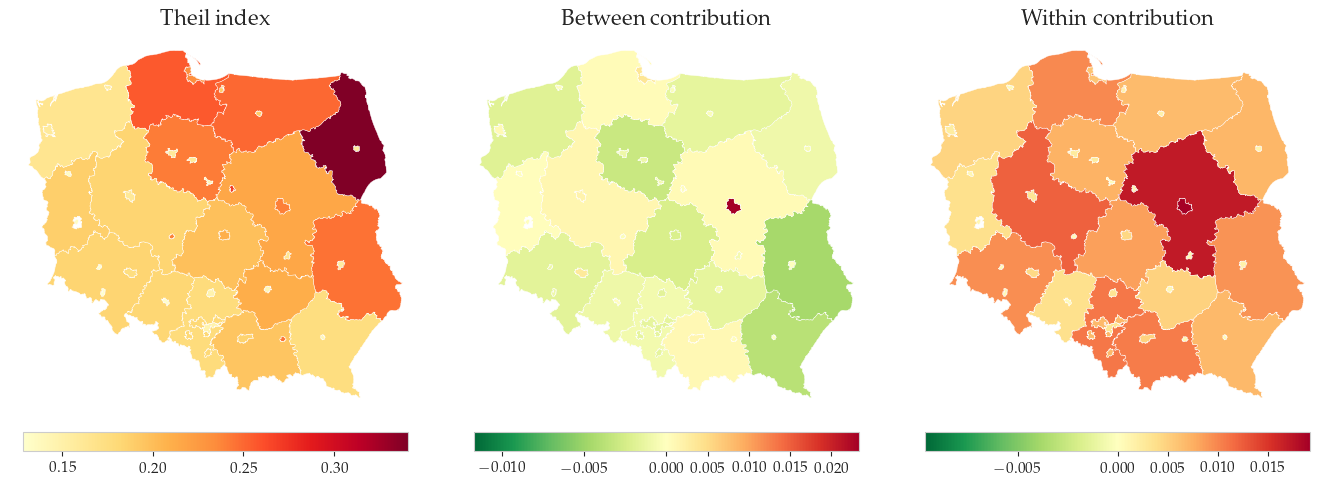

In [15]:
# ── Map: Theil index & contributions — LIS only (YEAR) ───────────────────────
# LIS regional metrics
lis_reg_lis = lis_groups_a.regional_panel(metrics=['theil'])
lis_reg_lis = lis_reg_lis[lis_reg_lis['year'] == YEAR].copy()
# LIS contributions
lis_ctr_lis = lis_contrib.copy()

# Plot definitions: (data, col, label, cmap, diverging)
plot_defs = [
    (lis_reg_lis, 'theil',                'Theil index',          'YlOrRd',   False),
    (lis_ctr_lis, 'between_contribution', 'Between contribution', 'RdYlGn_r', True),
    (lis_ctr_lis, 'within_contribution',  'Within contribution',  'RdYlGn_r', True),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.subplots_adjust(wspace=-1)

for col_idx, (data, val_col, label, cmap_name, diverging) in enumerate(plot_defs):
    vals = data.set_index('region' if 'region' in data.columns else 'group')[val_col]

    if diverging:
        vabs = max(abs(vals.min()), abs(vals.max()))
        norm = mpl.colors.TwoSlopeNorm(vmin=-vabs * 0.5, vcenter=0, vmax=vabs)
    else:
        norm = mpl.colors.Normalize(vmin=vals.min(), vmax=vals.max())
    cmap_map = mpl.colormaps[cmap_name]

    gdf_lis = region_gdf.copy()
    gdf_lis['value'] = gdf_lis['id'].map(vals)
    gdf_lis.plot(column='value', ax=axes[col_idx], legend=False, cmap=cmap_map, norm=norm,
                 edgecolor='white', linewidth=0.3)
    axes[col_idx].set_title(f'{label}', fontsize=16)
    axes[col_idx].axis('off')

    sm = plt.cm.ScalarMappable(cmap=cmap_map, norm=norm)
    fig.colorbar(sm, ax=axes[col_idx], orientation='horizontal', fraction=0.046, pad=0.04)

plt.savefig(PLOT_ROOT / f"theil_contributions_map_lis_groups_{YEAR}.png", bbox_inches='tight')
plt.show()

**Theil decomposition by voivodeship × city-size group — interpretation.**

The Theil T index is *exactly* decomposable: each group's contribution to national inequality has two additive parts:

$$T = \sum_g \underbrace{s_g \ln\!\left(\frac{\mu_g}{\mu}\right)}_{\text{between}_g} + \sum_g \underbrace{s_g \, T_g}_{\text{within}_g}$$

where $s_g = \frac{\sum_{i \in g} w_i y_i}{\sum_i w_i y_i}$ is the *income share* of group $g$ (voivodeship × city-size class).

Key findings:

- This finer grouping (voivodeship × {<100k, 100–500k, >500k}) captures **both** the regional and urban–rural dimensions of inequality simultaneously.
- Groups centred on large cities (especially Warsaw/Mazowieckie) tend to have the largest contributions, combining high within-group dispersion with above-average incomes.
- The between-group component is larger than in the pure voivodeship decomposition, because city-size variation within voivodeships now adds to the between-group term.
- Both CBOS and LIS show broadly consistent patterns, lending confidence to the measurement approach.